# Heart Disease Model — Training and Final Evaluation

## Notebook purpose
This notebook trains and evaluates the binary heart-disease classifier used by the application.

The experimental design separates the data into development, validation, and held-out test partitions. Because the dataset combines several UCI source cohorts, stratification incorporates both the disease target and dataset source where the split is created.

The workflow is:

1. Load the processed heart dataset.
2. Define numerical and categorical feature groups.
3. Reserve an untouched test set.
4. Build preprocessing pipelines for missing-value imputation, encoding, and scaling.
5. Compare Logistic Regression, Random Forest, and Gradient Boosting.
6. Select a model and validation-based decision threshold.
7. Refit the selected pipeline using all non-test data.
8. Evaluate once on the held-out test set.
9. Save the complete inference artifact and reporting figures.


In [1]:
from pathlib import Path
from time import perf_counter

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


# Locate the project root
current_folder = Path.cwd()

project_root = (
    current_folder.parent
    if current_folder.name == "notebooks"
    else current_folder
)

# Load the processed heart disease dataset
processed_data_path = (
    project_root
    / "data"
    / "processed"
    / "heart_disease_clean.csv"
)

heart_data = pd.read_csv(
    processed_data_path
)

# Define the target and medical input features
target_column = "heart_disease"

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

model_features = (
    numerical_features
    + categorical_features
)

X = heart_data[
    model_features
].copy()

y = heart_data[
    target_column
].astype(int)

dataset_source = heart_data[
    "dataset"
].copy()

# Combine the target and source for balanced splitting
stratification_labels = (
    dataset_source.astype(str)
    + "__"
    + y.astype(str)
)

# Reserve 20 percent of the data for final testing
(
    X_remaining,
    X_test,
    y_remaining,
    y_test,
    source_remaining,
    source_test
) = train_test_split(
    X,
    y,
    dataset_source,
    test_size=0.20,
    random_state=42,
    stratify=stratification_labels
)

# Build labels for the development-validation split
remaining_stratification_labels = (
    source_remaining.astype(str)
    + "__"
    + y_remaining.astype(str)
)

# Reserve 20 percent of the remaining data for validation
(
    X_development,
    X_validation,
    y_development,
    y_validation,
    source_development,
    source_validation
) = train_test_split(
    X_remaining,
    y_remaining,
    source_remaining,
    test_size=0.20,
    random_state=123,
    stratify=remaining_stratification_labels
)

# Display the resulting dataset dimensions
print(
    "Full dataset shape:",
    heart_data.shape
)

print(
    "Development features shape:",
    X_development.shape
)

print(
    "Validation features shape:",
    X_validation.shape
)

print(
    "Testing features shape:",
    X_test.shape
)

# Display target percentages in every partition
for partition_name, partition_target in [
    ("Development", y_development),
    ("Validation", y_validation),
    ("Testing", y_test)
]:
    print(
        f"\n{partition_name} target distribution:"
    )

    print(
        partition_target
        .value_counts(
            normalize=True
        )
        .sort_index()
        .mul(100)
        .round(2)
    )

# Display source and target counts in every partition
for (
    partition_name,
    partition_source,
    partition_target
) in [
    (
        "Development",
        source_development,
        y_development
    ),
    (
        "Validation",
        source_validation,
        y_validation
    ),
    (
        "Testing",
        source_test,
        y_test
    )
]:
    print(
        f"\n{partition_name} source-target table:"
    )

    display(
        pd.crosstab(
            partition_source,
            partition_target
        )
    )

# Verify that no record appears in more than one partition
development_indices = set(
    X_development.index
)

validation_indices = set(
    X_validation.index
)

test_indices = set(
    X_test.index
)

print(
    "\nDevelopment-validation overlap:",
    len(
        development_indices
        & validation_indices
    )
)

print(
    "Development-test overlap:",
    len(
        development_indices
        & test_indices
    )
)

print(
    "Validation-test overlap:",
    len(
        validation_indices
        & test_indices
    )
)

Full dataset shape: (920, 15)
Development features shape: (588, 13)
Validation features shape: (148, 13)
Testing features shape: (184, 13)

Development target distribution:
heart_disease
0    44.73
1    55.27
Name: proportion, dtype: float64

Validation target distribution:
heart_disease
0    44.59
1    55.41
Name: proportion, dtype: float64

Testing target distribution:
heart_disease
0    44.57
1    55.43
Name: proportion, dtype: float64

Development source-target table:


heart_disease,0,1
dataset,,
Cleveland,105,89
Hungary,120,68
Switzerland,5,73
VA Long Beach,33,95



Validation source-target table:


heart_disease,0,1
dataset,,
Cleveland,27,22
Hungary,30,17
Switzerland,1,19
VA Long Beach,8,24



Testing source-target table:


heart_disease,0,1
dataset,,
Cleveland,33,28
Hungary,37,21
Switzerland,2,23
VA Long Beach,10,30



Development-validation overlap: 0
Development-test overlap: 0
Validation-test overlap: 0


## 1. Preprocessing, Metrics, Baseline, and Logistic Regression

The heart dataset contains both numerical and categorical variables, so preprocessing is performed inside a `ColumnTransformer`.

### Numerical preprocessing
- Missing values are replaced with the median.
- Missing-value indicators are added.
- Features are standardized.

### Categorical preprocessing
- Missing values are replaced with the most frequent category.
- Categories are converted using one-hot encoding.
- Previously unseen categories are ignored safely during inference.

A majority-class dummy model establishes the minimum baseline. Logistic Regression is then trained as the first real candidate using the same preprocessing pipeline.

Keeping preprocessing inside the pipeline ensures that transformations are fitted only from the training data.


In [2]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)


def evaluate_binary_model(
    model_name,
    true_labels,
    predictions,
    probability_scores
):
    """Calculate the main binary classification metrics."""
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            true_labels,
            predictions
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            true_labels,
            predictions
        ),
        "Precision": precision_score(
            true_labels,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            true_labels,
            predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            true_labels,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            true_labels,
            probability_scores
        ),
        "PR-AUC": average_precision_score(
            true_labels,
            probability_scores
        )
    }


# Build the numerical preprocessing pipeline
numerical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Build the categorical preprocessing pipeline
categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combine numerical and categorical preprocessing
heart_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_preprocessor,
            numerical_features
        ),
        (
            "categorical",
            categorical_preprocessor,
            categorical_features
        )
    ],
    remainder="drop"
)

# Train the majority-class baseline
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(
    X_development,
    y_development
)

baseline_predictions = baseline_model.predict(
    X_validation
)

baseline_scores = baseline_model.predict_proba(
    X_validation
)[:, 1]

baseline_results = evaluate_binary_model(
    "Majority Class Baseline",
    y_validation,
    baseline_predictions,
    baseline_scores
)

baseline_results["Training Time (s)"] = np.nan

# Build the logistic regression pipeline
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(
                               heart_preprocessor
            )
        ),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

# Train the logistic regression model
training_start = perf_counter()

logistic_model.fit(
    X_development,
    y_development
)

logistic_training_time = (
    perf_counter() - training_start
)

# Generate validation predictions and scores
logistic_predictions = logistic_model.predict(
    X_validation
)

logistic_scores = logistic_model.predict_proba(
    X_validation
)[:, 1]

logistic_results = evaluate_binary_model(
    "Logistic Regression",
    y_validation,
    logistic_predictions,
    logistic_scores
)

logistic_results["Training Time (s)"] = (
    logistic_training_time
)

validation_results = [
    baseline_results,
    logistic_results
]

# Display the initial model comparison
display(
    pd.DataFrame(
        validation_results
    )
    .set_index("Model")
    .round(4)
)

print(
    "Logistic regression confusion matrix:"
)

print(
    confusion_matrix(
        y_validation,
        logistic_predictions
    )
)

print(
    "\nTraining time:",
    round(
        logistic_training_time,
        4
    ),
    "seconds"
)

,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Training Time (s)
Model,,,,,,,,
Majority Class Baseline,0.5541,0.5000,0.5541,1.0000,0.7130,0.5000,0.5541,NaN
Logistic Regression,0.7703,0.7779,0.8529,0.7073,0.7733,0.8572,0.8583,0.662


Logistic regression confusion matrix:
[[56 10]
 [24 58]]

Training time: 0.662 seconds


## 2. Random Forest Candidate

Random Forest is evaluated as a nonlinear ensemble alternative.

The model combines many decision trees and uses:

- Controlled maximum depth.
- A minimum leaf size.
- Random feature selection.
- Balanced subsampling.

These settings reduce overfitting and account for class imbalance. Validation predictions, probability scores, evaluation metrics, confusion matrix, and training time are recorded for direct comparison with Logistic Regression.


In [3]:
from sklearn.ensemble import RandomForestClassifier


# Build the random forest pipeline
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(
                heart_preprocessor
            )
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=8,
                min_samples_leaf=3,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the random forest model
training_start = perf_counter()

random_forest_model.fit(
    X_development,
    y_development
)

random_forest_training_time = (
    perf_counter() - training_start
)

# Generate validation predictions and scores
random_forest_predictions = (
    random_forest_model.predict(
        X_validation
    )
)

random_forest_scores = (
    random_forest_model.predict_proba(
        X_validation
    )[:, 1]
)

# Evaluate the random forest model
random_forest_results = evaluate_binary_model(
    "Random Forest",
    y_validation,
    random_forest_predictions,
    random_forest_scores
)

random_forest_results["Training Time (s)"] = (
    random_forest_training_time
)

validation_results.append(
    random_forest_results
)

# Display the updated model comparison
display(
    pd.DataFrame(
        validation_results
    )
    .set_index("Model")
    .round(4)
)

print(
    "Random forest confusion matrix:"
)

print(
    confusion_matrix(
        y_validation,
        random_forest_predictions
    )
)

print(
    "\nTraining time:",
    round(
        random_forest_training_time,
        4
    ),
    "seconds"
)


,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Training Time (s)
Model,,,,,,,,
Majority Class Baseline,0.5541,0.5000,0.5541,1.0000,0.7130,0.5000,0.5541,NaN
Logistic Regression,0.7703,0.7779,0.8529,0.7073,0.7733,0.8572,0.8583,0.6620
Random Forest,0.7703,0.7720,0.8158,0.7561,0.7848,0.8542,0.8331,2.1599


Random forest confusion matrix:
[[52 14]
 [20 62]]

Training time: 2.1599 seconds


## 3. Gradient Boosting Candidate

Gradient Boosting is the third candidate model.

It builds trees sequentially so that each stage attempts to reduce the prediction errors left by previous stages. A small learning rate, shallow trees, minimum leaf size, and subsampling are used to control model complexity.

Its validation results are added to the common model-comparison table.


In [4]:
from sklearn.ensemble import GradientBoostingClassifier


# Build the gradient boosting pipeline
gradient_boosting_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(
                heart_preprocessor
            )
        ),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.03,
                max_depth=2,
                min_samples_leaf=5,
                subsample=0.8,
                random_state=42
            )
        )
    ]
)

# Train the gradient boosting model
training_start = perf_counter()

gradient_boosting_model.fit(
    X_development,
    y_development
)

gradient_boosting_training_time = (
    perf_counter() - training_start
)

# Generate validation predictions and scores
gradient_boosting_predictions = (
    gradient_boosting_model.predict(
        X_validation
    )
)

gradient_boosting_scores = (
    gradient_boosting_model.predict_proba(
        X_validation
    )[:, 1]
)

# Evaluate the gradient boosting model
gradient_boosting_results = evaluate_binary_model(
    "Gradient Boosting",
    y_validation,
    gradient_boosting_predictions,
    gradient_boosting_scores
)

gradient_boosting_results[
    "Training Time (s)"
] = gradient_boosting_training_time

validation_results.append(
    gradient_boosting_results
)

# Display the complete validation comparison
display(
    pd.DataFrame(
        validation_results
    )
    .set_index("Model")
    .round(4)
)

print(
    "Gradient boosting confusion matrix:"
)

print(
    confusion_matrix(
        y_validation,
        gradient_boosting_predictions
    )
)

print(
    "\nTraining time:",
    round(
        gradient_boosting_training_time,
        4
    ),
    "seconds"
)

,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Training Time (s)
Model,,,,,,,,
Majority Class Baseline,0.5541,0.5000,0.5541,1.0000,0.7130,0.5000,0.5541,NaN
Logistic Regression,0.7703,0.7779,0.8529,0.7073,0.7733,0.8572,0.8583,0.6620
Random Forest,0.7703,0.7720,0.8158,0.7561,0.7848,0.8542,0.8331,2.1599
Gradient Boosting,0.7973,0.7979,0.8333,0.7927,0.8125,0.8545,0.8266,0.8342


Gradient boosting confusion matrix:
[[53 13]
 [17 65]]

Training time: 0.8342 seconds


## 4. Validation-Based Model and Threshold Selection

Each trained candidate is evaluated over possible decision thresholds.

The threshold-search function requires at least 75% recall and then selects the point with the highest F1 score among eligible thresholds. This avoids treating `0.50` as an automatically optimal cutoff.

After threshold tuning, the candidate models are ranked by their tuned F1 score. The selected model and threshold are fixed **before** the test set is evaluated.

This is a critical methodological step because the test set must not influence model or threshold selection.


In [5]:
from sklearn.metrics import precision_recall_curve


def find_best_threshold(
    true_labels,
    probability_scores,
    minimum_recall=0.75
):
    """Find the highest-F1 threshold that satisfies minimum recall."""
    precision_values, recall_values, thresholds = (
        precision_recall_curve(
            true_labels,
            probability_scores
        )
    )

    threshold_table = pd.DataFrame(
        {
            "Threshold": thresholds,
            "Precision": precision_values[:-1],
            "Recall": recall_values[:-1]
        }
    )

    threshold_table["F1 Score"] = (
        2
        * threshold_table["Precision"]
        * threshold_table["Recall"]
        / (
            threshold_table["Precision"]
            + threshold_table["Recall"]
            + 1e-10
        )
    )

    eligible_thresholds = threshold_table[
        threshold_table["Recall"]
        >= minimum_recall
    ].copy()

    best_row = eligible_thresholds.loc[
        eligible_thresholds[
            "F1 Score"
        ].idxmax()
    ]

    return float(
        best_row["Threshold"]
    )


# Store each trained model and its validation scores
candidate_models = {
    "Logistic Regression": {
        "model": logistic_model,
        "scores": logistic_scores
    },
    "Random Forest": {
        "model": random_forest_model,
        "scores": random_forest_scores
    },
    "Gradient Boosting": {
        "model": gradient_boosting_model,
        "scores": gradient_boosting_scores
    }
}

tuned_validation_results = []

# Tune and evaluate every candidate model
for model_name, model_information in (
    candidate_models.items()
):
    model_scores = model_information[
        "scores"
    ]

    tuned_threshold = find_best_threshold(
        y_validation,
        model_scores,
        minimum_recall=0.75
    )

    tuned_predictions = (
        model_scores
        >= tuned_threshold
    ).astype(int)

    tuned_result = evaluate_binary_model(
        model_name,
        y_validation,
        tuned_predictions,
        model_scores
    )

    tuned_result["Threshold"] = (
        tuned_threshold
    )

    tuned_validation_results.append(
        tuned_result
    )

# Create the tuned model comparison table
tuned_comparison = (
    pd.DataFrame(
        tuned_validation_results
    )
    .set_index("Model")
    .sort_values(
        "F1 Score",
        ascending=False
    )
)

display(
    tuned_comparison.round(4)
)

# Select the model with the highest constrained F1 score
selected_model_name = (
    tuned_comparison.index[0]
)

selected_threshold = float(
    tuned_comparison.loc[
        selected_model_name,
        "Threshold"
    ]
)

selected_heart_model = (
    candidate_models[
        selected_model_name
    ]["model"]
)

selected_validation_scores = (
    candidate_models[
        selected_model_name
    ]["scores"]
)

selected_validation_predictions = (
    selected_validation_scores
    >= selected_threshold
).astype(int)

print(
    "Selected model:",
    selected_model_name
)

print(
    "Selected threshold:",
    round(
        selected_threshold,
        4
    )
)

print(
    "Selected model confusion matrix:"
)

print(
    confusion_matrix(
        y_validation,
        selected_validation_predictions
    )
)

,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Threshold
Model,,,,,,,,
Logistic Regression,0.8176,0.8088,0.8022,0.8902,0.8439,0.8572,0.8583,0.3131
Random Forest,0.8108,0.8041,0.8068,0.8659,0.8353,0.8542,0.8331,0.3693
Gradient Boosting,0.7973,0.7816,0.7600,0.9268,0.8352,0.8545,0.8266,0.2986


Selected model: Logistic Regression
Selected threshold: 0.3131
Selected model confusion matrix:
[[48 18]
 [ 9 73]]


## 5. Final Refit and Held-Out Test Evaluation

A fresh copy of the selected pipeline is trained using all available development and validation data.

The model then generates scores for the reserved test set, and the previously selected threshold converts those scores into final class predictions.

The resulting metrics and confusion matrix represent the official held-out performance of the heart-disease module. No additional tuning should be performed using these test results.


In [6]:
# Create a fresh copy of the selected pipeline
final_heart_model = clone(
    selected_heart_model
)

# Train the final model using development and validation data
final_training_start = perf_counter()

final_heart_model.fit(
    X_remaining,
    y_remaining
)

final_training_time = (
    perf_counter()
    - final_training_start
)

# Generate probability scores for the reserved test set
final_test_scores = (
    final_heart_model.predict_proba(
        X_test
    )[:, 1]
)

# Apply the threshold selected on validation data
final_test_predictions = (
    final_test_scores
    >= selected_threshold
).astype(int)

# Evaluate the final model on the reserved test set
final_test_results = evaluate_binary_model(
    "Final Heart Logistic Regression",
    y_test,
    final_test_predictions,
    final_test_scores
)

final_test_results["Threshold"] = (
    selected_threshold
)

final_test_results["Training Time (s)"] = (
    final_training_time
)

# Display the official final test results
display(
    pd.DataFrame(
        [final_test_results]
    )
    .set_index("Model")
    .round(4)
)

print(
    "Final heart disease test confusion matrix:"
)

print(
    confusion_matrix(
        y_test,
        final_test_predictions
    )
)

print(
    "\nFinal training time:",
    round(
        final_training_time,
        4
    ),
    "seconds"
)

,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Threshold,Training Time (s)
Model,,,,,,,,,
Final Heart Logistic Regression,0.8478,0.8388,0.8246,0.9216,0.8704,0.9085,0.9188,0.3131,0.159


Final heart disease test confusion matrix:
[[62 20]
 [ 8 94]]

Final training time: 0.159 seconds


## 6. Saving and Verifying the Heart Model Package

The deployment artifact stores more than the fitted classifier. It also records:

- The decision threshold.
- The required feature names and their order.
- Numerical and categorical feature groups.
- Target and model names.
- Dataset-source metadata.
- Final test metrics.

The artifact is saved with `joblib`, reloaded, and used to generate verification predictions. This confirms that the serialized object is ready for the Streamlit application.


In [7]:
# Create the models folder if it does not exist
models_folder = (
    project_root
    / "models"
)

models_folder.mkdir(
    parents=True,
    exist_ok=True
)

# Define the final heart model path
heart_model_path = (
    models_folder
    / "heart_disease_model.joblib"
)

# Create the complete heart model package
heart_model_package = {
    "model": final_heart_model,
    "threshold": selected_threshold,
    "feature_names": model_features,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "target_name": target_column,
    "model_name": selected_model_name,
    "dataset_name": "UCI Heart Disease Dataset",
    "dataset_sources": [
        "Cleveland",
        "Hungary",
        "Switzerland",
        "VA Long Beach"
    ],
    "test_metrics": final_test_results
}

# Save the complete model package
joblib.dump(
    heart_model_package,
    heart_model_path
)

# Load the saved package to verify it
loaded_heart_package = joblib.load(
    heart_model_path
)

verification_scores = (
    loaded_heart_package["model"]
    .predict_proba(
        X_test.iloc[:5]
    )[:, 1]
)

verification_predictions = (
    verification_scores
    >= loaded_heart_package[
        "threshold"
    ]
).astype(int)

print(
    "Heart model saved successfully:",
    heart_model_path.exists()
)

print(
    "Saved model path:",
    heart_model_path
)

print(
    "Saved model name:",
    loaded_heart_package[
        "model_name"
    ]
)

print(
    "Saved threshold:",
    loaded_heart_package[
        "threshold"
    ]
)

print(
    "Number of saved features:",
    len(
        loaded_heart_package[
            "feature_names"
        ]
    )
)

print(
    "Verification scores:",
    np.round(
        verification_scores,
        4
    )
)

print(
    "Verification predictions:",
    verification_predictions
)

Heart model saved successfully: True
Saved model path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\models\heart_disease_model.joblib
Saved model name: Logistic Regression
Saved threshold: 0.3131017984869792
Number of saved features: 13
Verification scores: [0.0409 0.7527 0.1497 0.9822 0.3028]
Verification predictions: [0 1 0 1 0]


## 7. Final Evaluation Visualization

The final test performance is summarized using:

- A confusion matrix.
- A Receiver Operating Characteristic curve.
- A precision-recall curve.

ROC-AUC evaluates ranking discrimination across thresholds, while the precision-recall curve provides a direct view of the balance between detecting positive cases and controlling false positives.

The generated figure is saved for use in the final report.


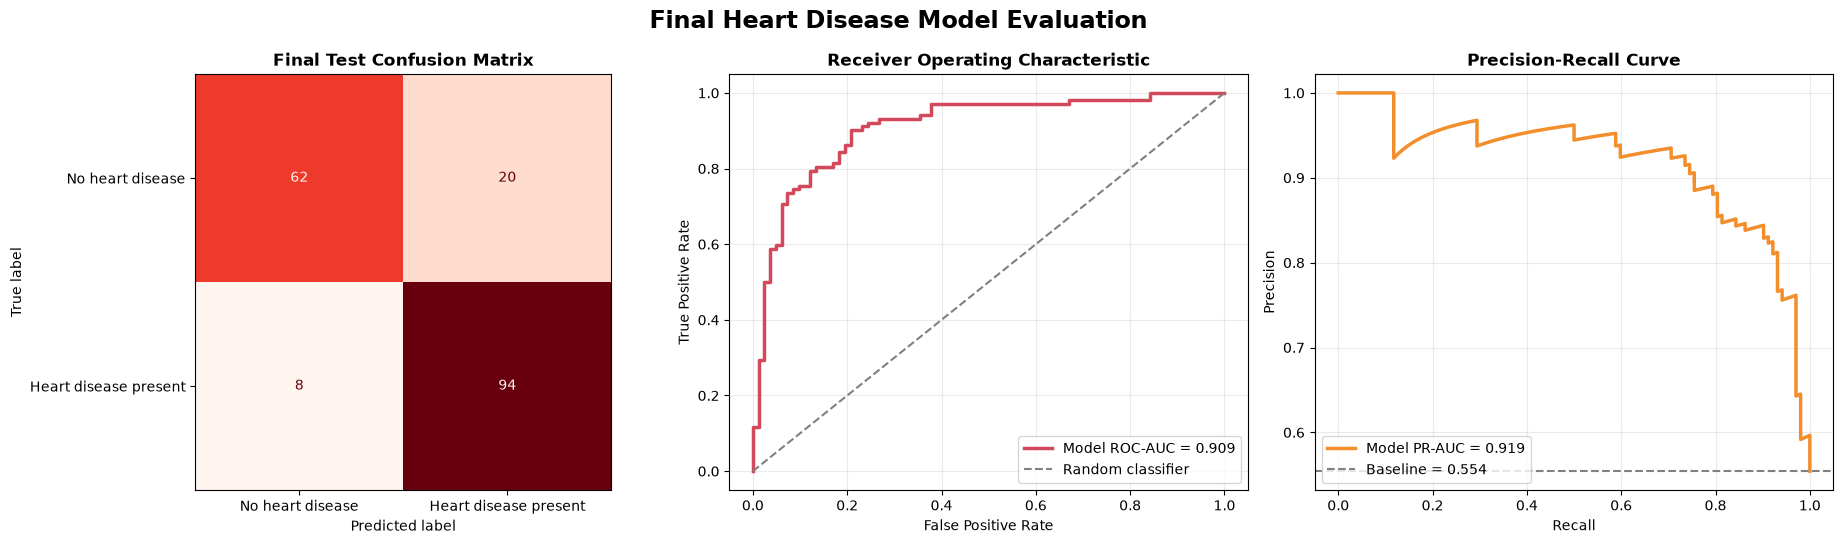

Evaluation figure saved: True
Evaluation figure path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\heart_final_model_evaluation.png


In [8]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    auc,
    precision_recall_curve,
    roc_curve
)


# Create the reports figures folder
figures_folder = (
    project_root
    / "reports"
    / "figures"
)

figures_folder.mkdir(
    parents=True,
    exist_ok=True
)

# Calculate the final confusion matrix
final_confusion_matrix = confusion_matrix(
    y_test,
    final_test_predictions
)

# Calculate the ROC curve
false_positive_rate, true_positive_rate, _ = (
    roc_curve(
        y_test,
        final_test_scores
    )
)

roc_auc_value = auc(
    false_positive_rate,
    true_positive_rate
)

# Calculate the precision-recall curve
pr_precision, pr_recall, _ = (
    precision_recall_curve(
        y_test,
        final_test_scores
    )
)

positive_class_rate = y_test.mean()

# Create the final evaluation figure
figure, axes = plt.subplots(
    1,
    3,
    figsize=(19, 5.5)
)

# Plot the confusion matrix
confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=[
        "No heart disease",
        "Heart disease present"
    ]
)

confusion_display.plot(
    ax=axes[0],
    cmap="Reds",
    colorbar=False,
    values_format=",d"
)

axes[0].set_title(
    "Final Test Confusion Matrix",
    fontweight="bold"
)

# Plot the ROC curve
axes[1].plot(
    false_positive_rate,
    true_positive_rate,
    color="#D1495B",
    linewidth=2.5,
    label=(
        f"Model ROC-AUC = "
        f"{roc_auc_value:.3f}"
    )
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)

axes[1].set_title(
    "Receiver Operating Characteristic",
    fontweight="bold"
)

axes[1].set_xlabel(
    "False Positive Rate"
)

axes[1].set_ylabel(
    "True Positive Rate"
)

axes[1].legend(
    loc="lower right"
)

axes[1].grid(
    alpha=0.25
)

# Plot the precision-recall curve
axes[2].plot(
    pr_recall,
    pr_precision,
    color="#F28E2B",
    linewidth=2.5,
    label=(
        f"Model PR-AUC = "
        f"{final_test_results['PR-AUC']:.3f}"
    )
)

axes[2].axhline(
    positive_class_rate,
    linestyle="--",
    color="gray",
    label=(
        f"Baseline = "
        f"{positive_class_rate:.3f}"
    )
)

axes[2].set_title(
    "Precision-Recall Curve",
    fontweight="bold"
)

axes[2].set_xlabel(
    "Recall"
)

axes[2].set_ylabel(
    "Precision"
)

axes[2].legend(
    loc="lower left"
)

axes[2].grid(
    alpha=0.25
)

figure.suptitle(
    "Final Heart Disease Model Evaluation",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

# Save the final evaluation figure
evaluation_figure_path = (
    figures_folder
    / "heart_final_model_evaluation.png"
)

plt.savefig(
    evaluation_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Evaluation figure saved:",
    evaluation_figure_path.exists()
)

print(
    "Evaluation figure path:",
    evaluation_figure_path
)

## 8. Permutation Feature Importance

Permutation importance is calculated by shuffling one original feature at a time and measuring the reduction in average precision.

Features that cause larger performance drops are more important to this specific trained model.

This technique improves interpretability, but the result should not be interpreted as proof that a feature medically causes heart disease. It reflects predictive dependence within this dataset and fitted model.


,Feature,Importance,Standard Deviation
0,cp,0.0526,0.0124
1,oldpeak,0.0285,0.0115
2,chol,0.0199,0.0137
3,exang,0.0151,0.0085
4,thalch,0.0132,0.0074
5,thal,0.0122,0.0071
6,sex,0.0091,0.0065
7,ca,0.0084,0.0100
8,trestbps,0.0069,0.0081
9,fbs,0.0027,0.0026


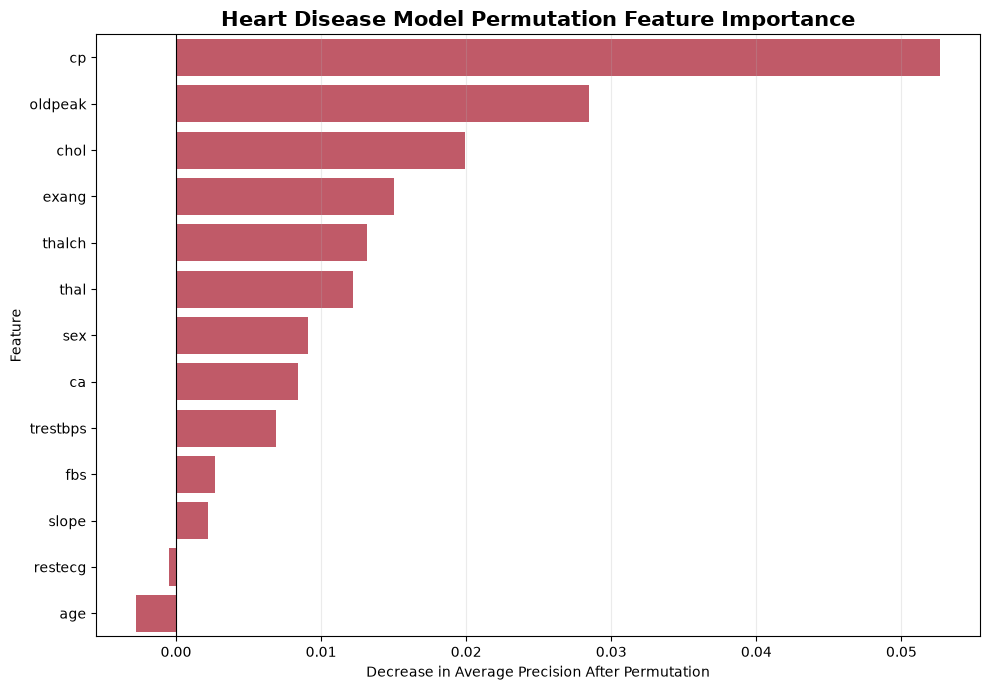

Feature importance figure saved: True
Feature importance figure path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\heart_feature_importance.png


In [9]:
from sklearn.inspection import permutation_importance


# Calculate raw feature importance on the test set
permutation_results = permutation_importance(
    final_heart_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

# Create the feature importance table
heart_feature_importance = pd.DataFrame(
    {
        "Feature": model_features,
        "Importance": (
            permutation_results.importances_mean
        ),
        "Standard Deviation": (
            permutation_results.importances_std
        )
    }
)

heart_feature_importance = (
    heart_feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    heart_feature_importance.round(4)
)

# Create the feature importance chart
plt.figure(
    figsize=(10, 7)
)

sns.barplot(
    data=heart_feature_importance,
    x="Importance",
    y="Feature",
    color="#D1495B"
)

plt.axvline(
    0,
    color="black",
    linewidth=0.8
)

plt.title(
    "Heart Disease Model Permutation Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Decrease in Average Precision After Permutation"
)

plt.ylabel(
    "Feature"
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

# Save the feature importance figure
feature_importance_path = (
    figures_folder
    / "heart_feature_importance.png"
)

plt.savefig(
    feature_importance_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Feature importance figure saved:",
    feature_importance_path.exists()
)

print(
    "Feature importance figure path:",
    feature_importance_path
)